Baixando uma imagem de teste...
Plotando o que a rede enxergou na primeira camada:


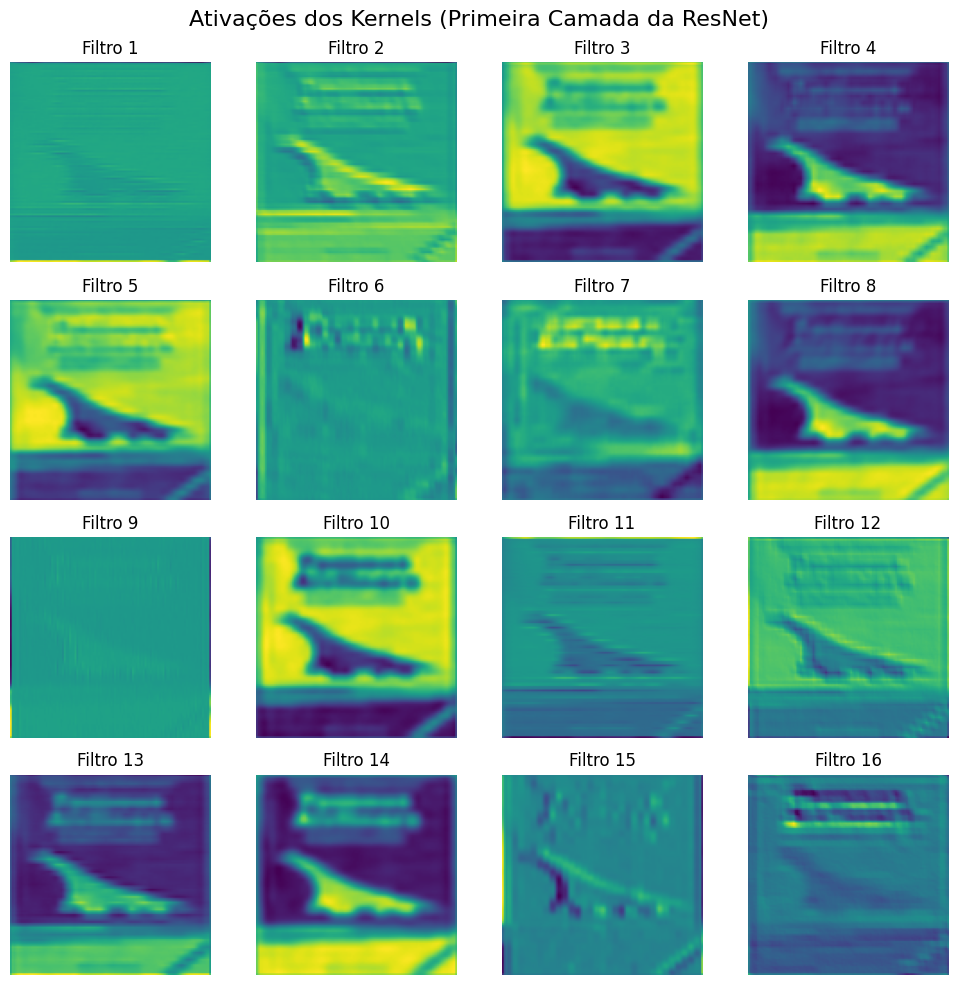

In [1]:
import torch
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms
from torchvision import models

# Puxando a rede pré-treinada de novo só pra garantir que temos os pesos bons
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet.eval() # Modo de avaliação, desliga dropout e afins

# Preparando a imagem (usando o mesmo tamanho 224x224 que a resnet gosta)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

print("Baixando uma imagem de teste...")
dataset = torchvision.datasets.CIFAR10(root='../data', train=False, download=True, transform=transform)

# Pegando a imagem de índice 3 
imagem, label = dataset[3] 

# O PyTorch exige que a imagem esteja num "lote" (batch). 
# Como temos 1 imagem só, criamos uma dimensão falsa no começo.
# Shape vai de [3, 224, 224] para [1, 3, 224, 224]
imagem_batch = imagem.unsqueeze(0)

# O pulo do gato: passando a imagem APENAS pela primeira camada da rede (conv1)
with torch.no_grad():
    ativacoes = resnet.conv1(imagem_batch)

# A camada conv1 gera 64 "visões" diferentes da imagem. 
# Tiramos a dimensão do batch pra ficar só [64, 112, 112]
ativacoes = ativacoes.squeeze(0)

print("Plotando o que a rede enxergou na primeira camada:")

# Criando um grid 4x4 pra plotar os 16 primeiros kernels (filtros)
fig, axes = plt.subplots(4, 4, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    # Pega o mapa de ativação i e converte pra numpy pra plotar
    mapa = ativacoes[i].numpy()
    
    # cmap='viridis' deixa com aquelas cores bonitas de mapa de calor
    ax.imshow(mapa, cmap='viridis')
    ax.axis('off')
    ax.set_title(f'Filtro {i+1}')

plt.suptitle('Ativações dos Kernels (Primeira Camada da ResNet)', fontsize=16)
plt.tight_layout()
plt.show()